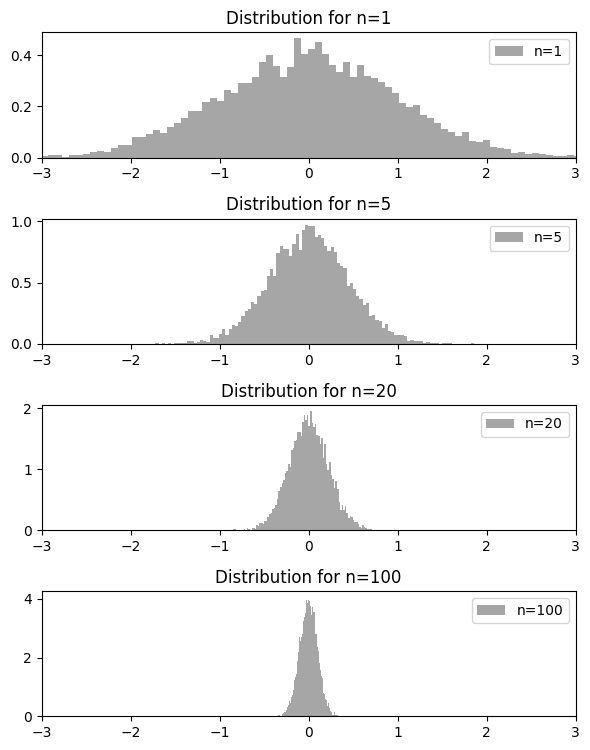

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_values = [1, 5, 20, 100]
samples = 10000

# Create a figure with subplots, one for each n_value
fig, axes = plt.subplots(nrows=len(n_values), figsize=(6, 2 * len(n_values)))

# Define a common x-axis limit based on the largest spread (n=1, std=1)
# Most values for N(0,1) fall within [-3, 3]
common_xlim = [-3, 3]

for i, n in enumerate(n_values):
    Xn = np.random.normal(0, np.sqrt(1/n), size=samples)
    axes[i].hist(Xn, bins=100, density=True, alpha=0.7, color='gray', label=f"n={n}")
    axes[i].set_title(f"Distribution for n={n}")
    axes[i].legend()
    axes[i].set_xlim(common_xlim) # Set the common x-axis limit

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for the suptitle
plt.savefig("convergence_dist.pdf" ) # Save the figure to a PDF file
plt.show()

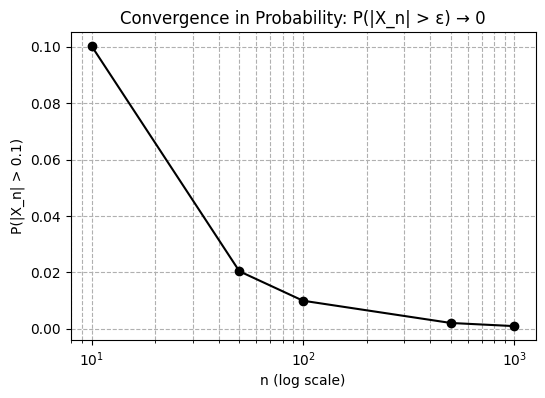

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_values = [10, 50, 100, 500, 1000]
samples = 100000
epsilon = 0.1

probabilities = []

for n in n_values:
    Xn = np.random.binomial(1, 1/n, size=samples) # Simulating X_n as Bernoulli with p=1/n
    prob = np.mean(np.abs(Xn - 0) > epsilon) # P(|X_n - 0| > epsilon)
    probabilities.append(prob)

plt.figure(figsize=(6, 4))
plt.plot(n_values, probabilities, marker='o', linestyle='-', color='black')
plt.xscale('log') # Use a logarithmic scale for n_values
plt.xlabel('n (log scale)')
plt.ylabel(f'P(|X_n| > {epsilon})')
plt.title('Convergence in Probability: P(|X_n| > ε) → 0')
plt.grid(True, which="both", ls="--")
plt.savefig("convergence_prob.pdf") # Save the figure to a PDF file
plt.show()

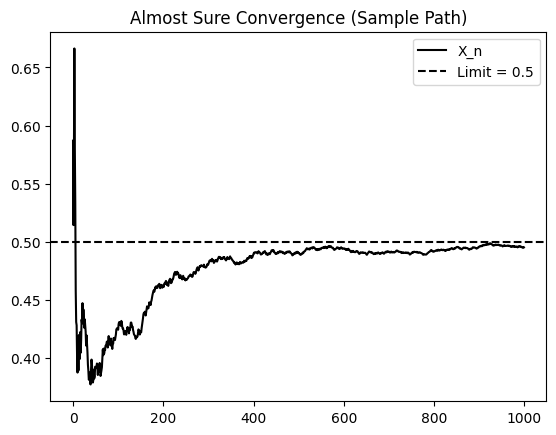

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 1000

# generate one sample path
U = np.random.uniform(0, 1, size=n)
X = np.cumsum(U) / np.arange(1, n+1)

plt.plot(X, label="X_n", color="black")
plt.axhline(0.5, linestyle="--", label="Limit = 0.5", color="black")

plt.title("Almost Sure Convergence (Sample Path)")
plt.legend()
plt.savefig("convergence_as.pdf" ) # Save the figure to a PDF file
plt.show()

In [ ]:
import numpy as np

def estimate_probability(n, num_sim=100000, threshold=40):
    # Simulate total lifetime of n bulbs
    lifetimes = np.random.normal(loc=3, scale=1, size=(num_sim, n))
    totals = lifetimes.sum(axis=1)

    # Estimate probability
    prob = np.mean(totals >= threshold)
    return prob

def find_min_bulbs(target_prob=0.9772, max_n=50):
    for n in range(1, max_n + 1):
        prob = estimate_probability(n)
        print(f"n = {n}, estimated P = {prob:.4f}")

        if prob >= target_prob:
            return n, prob

    return None, None

n, prob = find_min_bulbs()
print(f"\nMinimum number of bulbs needed: {n} (prob: {prob:.4f})")

n = 1, estimated P = 0.0000
n = 2, estimated P = 0.0000
n = 3, estimated P = 0.0000
n = 4, estimated P = 0.0000
n = 5, estimated P = 0.0000
n = 6, estimated P = 0.0000
n = 7, estimated P = 0.0000
n = 8, estimated P = 0.0000
n = 9, estimated P = 0.0000
n = 10, estimated P = 0.0007
n = 11, estimated P = 0.0171
n = 12, estimated P = 0.1224
n = 13, estimated P = 0.3884
n = 14, estimated P = 0.7037
n = 15, estimated P = 0.9027
n = 16, estimated P = 0.9774

Minimum number of bulbs needed: 16 (prob ≈ 0.9774)
